<a href="https://colab.research.google.com/github/RealGoldenGeneral/mini-project-7/blob/main/Object_Detection_in_Medical_Imaging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mini Project 7: Blood Cell Detection with YOLO26 (Option A - BCCD Dataset)
**Group 2: Aristide Kanamugire & Nicky Cheng**  
**Course:** COMP 9130 — Applied Artificial Intelligence  
**Dataset:** complete blood cell count.v1i.yolov8 (from Google Drive – Roboflow BCCD format, 3 classes: RBC, WBC, Platelets)


**1. Mount Google Drive & Setup**

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


!pip install -U ultralytics --quiet

# Import after install
from ultralytics import YOLO

import os
from IPython.display import Image, display
import yaml
import glob
from collections import defaultdict

print(" Ultralytics imported successfully!")
print("Version info:", YOLO.__module__)


try:
    test_model = YOLO('yolo26n.pt')
    print("Test load successful (yolo26n.pt)")
except Exception as e:
    print("Import/load test failed:", e)

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
 Ultralytics imported successfully!
Version info: ultralytics.models.yolo.model
Test load successful (yolo26n.pt)


**2. Dataset Preparation**

In [ ]:

dataset_folder_name = "complete blood cell count.v1i.yolov8"
base_drive_path = "/content/drive/MyDrive"
dataset_path = os.path.join(base_drive_path, dataset_folder_name)

print(f"Expected dataset location: {dataset_path}")


clean_name = "bccd_dataset"
clean_path = os.path.join(base_drive_path, clean_name)

if os.path.exists(dataset_path) and not os.path.exists(clean_path):
    os.rename(dataset_path, clean_path)
    dataset_path = clean_path
    print(f"Renamed folder to: {dataset_path}")
elif os.path.exists(clean_path):
    dataset_path = clean_path
    print("Using already renamed clean path")
else:
    print("Warning: folder not found – double-check Drive path and name")

# Verify basic structure
print("\nFolder contents:")
!ls -l "{dataset_path}"

data_yaml_path = os.path.join(dataset_path, "data.yaml")
if not os.path.exists(data_yaml_path):
    raise FileNotFoundError(f"data.yaml missing! Check folder: {dataset_path}")

print("\nLoading data.yaml...")
with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

print("Dataset config:")
print(data_config)

# Get class names & order dynamically
class_names = data_config.get('names', [])
nc = data_config.get('nc', len(class_names))
print(f"\nClasses ({nc}): {class_names}")

Expected dataset location: /content/drive/MyDrive/complete blood cell count.v1i.yolov8
Using already renamed clean path

Folder contents:
total 14
-rw------- 1 root root  330 Mar  4 01:34 data.yaml
-rw------- 1 root root  184 Mar  4 01:34 README.dataset.txt
-rw------- 1 root root 1004 Mar  4 01:34 README.roboflow.txt
drwx------ 2 root root 4096 Mar  4 01:34 test
drwx------ 2 root root 4096 Mar  4 01:38 train
drwx------ 2 root root 4096 Mar  4 01:34 valid

Loading data.yaml...
Dataset config:
{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 3, 'names': ['Platelets', 'RBC', 'WBC'], 'roboflow': {'workspace': 'university-of-macau-4pryf', 'project': 'complete-blood-cell-count', 'version': 1, 'license': 'Public Domain', 'url': 'https://universe.roboflow.com/university-of-macau-4pryf/complete-blood-cell-count/dataset/1'}}

Classes (3): ['Platelets', 'RBC', 'WBC']


**3. Model Training (YOLO26s from COCO pretrained)**
Minimum 25 epochs.

In [ ]:
def count_labels(split):
    counts = defaultdict(int)
    label_dir = os.path.join(dataset_path, split, "labels")
    if not os.path.exists(label_dir):
        return counts
    for txt_file in os.listdir(label_dir):
        if not txt_file.endswith('.txt'):
            continue
        with open(os.path.join(label_dir, txt_file), 'r') as f:
            for line in f:
                if line.strip():
                    cls_id = int(line.split()[0])
                    if 0 <= cls_id < nc:
                        counts[class_names[cls_id]] += 1
    return dict(counts)

print("Class distribution:")
for split in ['train', 'valid', 'test']:
    cnt = count_labels(split)
    total = sum(cnt.values())
    print(f"{split.capitalize()}: {cnt}  (total objects: {total})")

Class distribution:
Train: {'WBC': 244, 'Platelets': 255, 'RBC': 2640}  (total objects: 3139)
Valid: {'Platelets': 49, 'WBC': 63, 'RBC': 700}  (total objects: 812)
Test: {'RBC': 791, 'WBC': 61, 'Platelets': 55}  (total objects: 907)


**4. Evaluation  (mAP, Precision, Recall, Per-class, Confusion Matrix)**

In [ ]:


model = YOLO('yolo26s.pt')

results = model.train(
    data=data_yaml_path,
    epochs=25,
    imgsz=320,
    batch=4,
    name='bccd_yolo26s_group2_320',
    pretrained=True,
    optimizer='auto',
    seed=42,
    verbose=True,
    project='/content/runs/detect'
)

print(" Training completed successfully!")
print("Best weights saved at:", os.path.join(results.save_dir, "weights", "best.pt"))
print("All results saved in folder:", results.save_dir)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/bccd_dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=bccd_yolo26s_group2_320, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mas

**5.Detailed Individual Training Curves**

In [20]:


from ultralytics.utils.plotting import plot_results
import os
import matplotlib.pyplot as plt

run_dir = "/content/runs/detect/bccd_yolo26s_group2_320"
csv_file = os.path.join(run_dir, "results.csv")

if os.path.exists(csv_file):
    print("Generating EXACT same plots as our example report...")
    plot_results(file=csv_file)


    save_folder = os.path.join(run_dir, "individual_plots_for_report")
    os.makedirs(save_folder, exist_ok=True)

    print(f"\nSaving high-quality plots to:\n{save_folder}\n")

    for i, fig_num in enumerate(plt.get_fignums()):
        fig = plt.figure(fig_num)
        title = fig.canvas.get_window_title() or f"plot_{i+1}"
        filename = f"{title.replace(' ', '_').replace('/', '_')}.png"
        save_path = os.path.join(save_folder, filename)
        fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Saved: {filename}")

    print("\n SUCCESS! All plots saved and look exactly like the example report.")
    print("→ Download the whole 'individual_plots_for_report' folder now.")

else:
    print(" results.csv not found. Please run the training cell first.")

Generating EXACT same plots as our example report...

Saving high-quality plots to:
/content/runs/detect/bccd_yolo26s_group2_320/individual_plots_for_report


 SUCCESS! All plots saved and look exactly like the example report.
→ Download the whole 'individual_plots_for_report' folder now.


**6. Evaluation – Metrics**

In [11]:
val_results = model.val()

print("Overall Metrics:")
print(f"mAP@50     : {val_results.box.map50:.4f}")
print(f"mAP@50-95  : {val_results.box.map:.4f}")
print(f"Precision  : {val_results.box.mp:.4f}")
print(f"Recall     : {val_results.box.mr:.4f}")

print("\nPer-class mAP@50:")
for i, name in enumerate(data_config['names']):
    print(f"  {name}: {val_results.box.maps[i]:.4f}")

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO26s summary (fused): 122 layers, 9,466,341 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access ✅ (ping: 4.6±3.1 ms, read: 3.2±2.1 MB/s, size: 25.4 KB)
val: Scanning /content/drive/MyDrive/bccd_dataset/valid/labels.cache... 60 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60 5.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 4.0s/it 16.1s
                   all         60        812      0.823      0.882      0.904       0.62
             Platelets         35         49      0.756      0.887      0.888      0.474
                   RBC         57        700      0.748      0.776      0.835      0.573
                   WBC         60         63      0.965      0.984       0.99      0.813
Speed: 1.2ms preprocess, 228.9ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /content/runs/detect/va

## 7. Training Curves

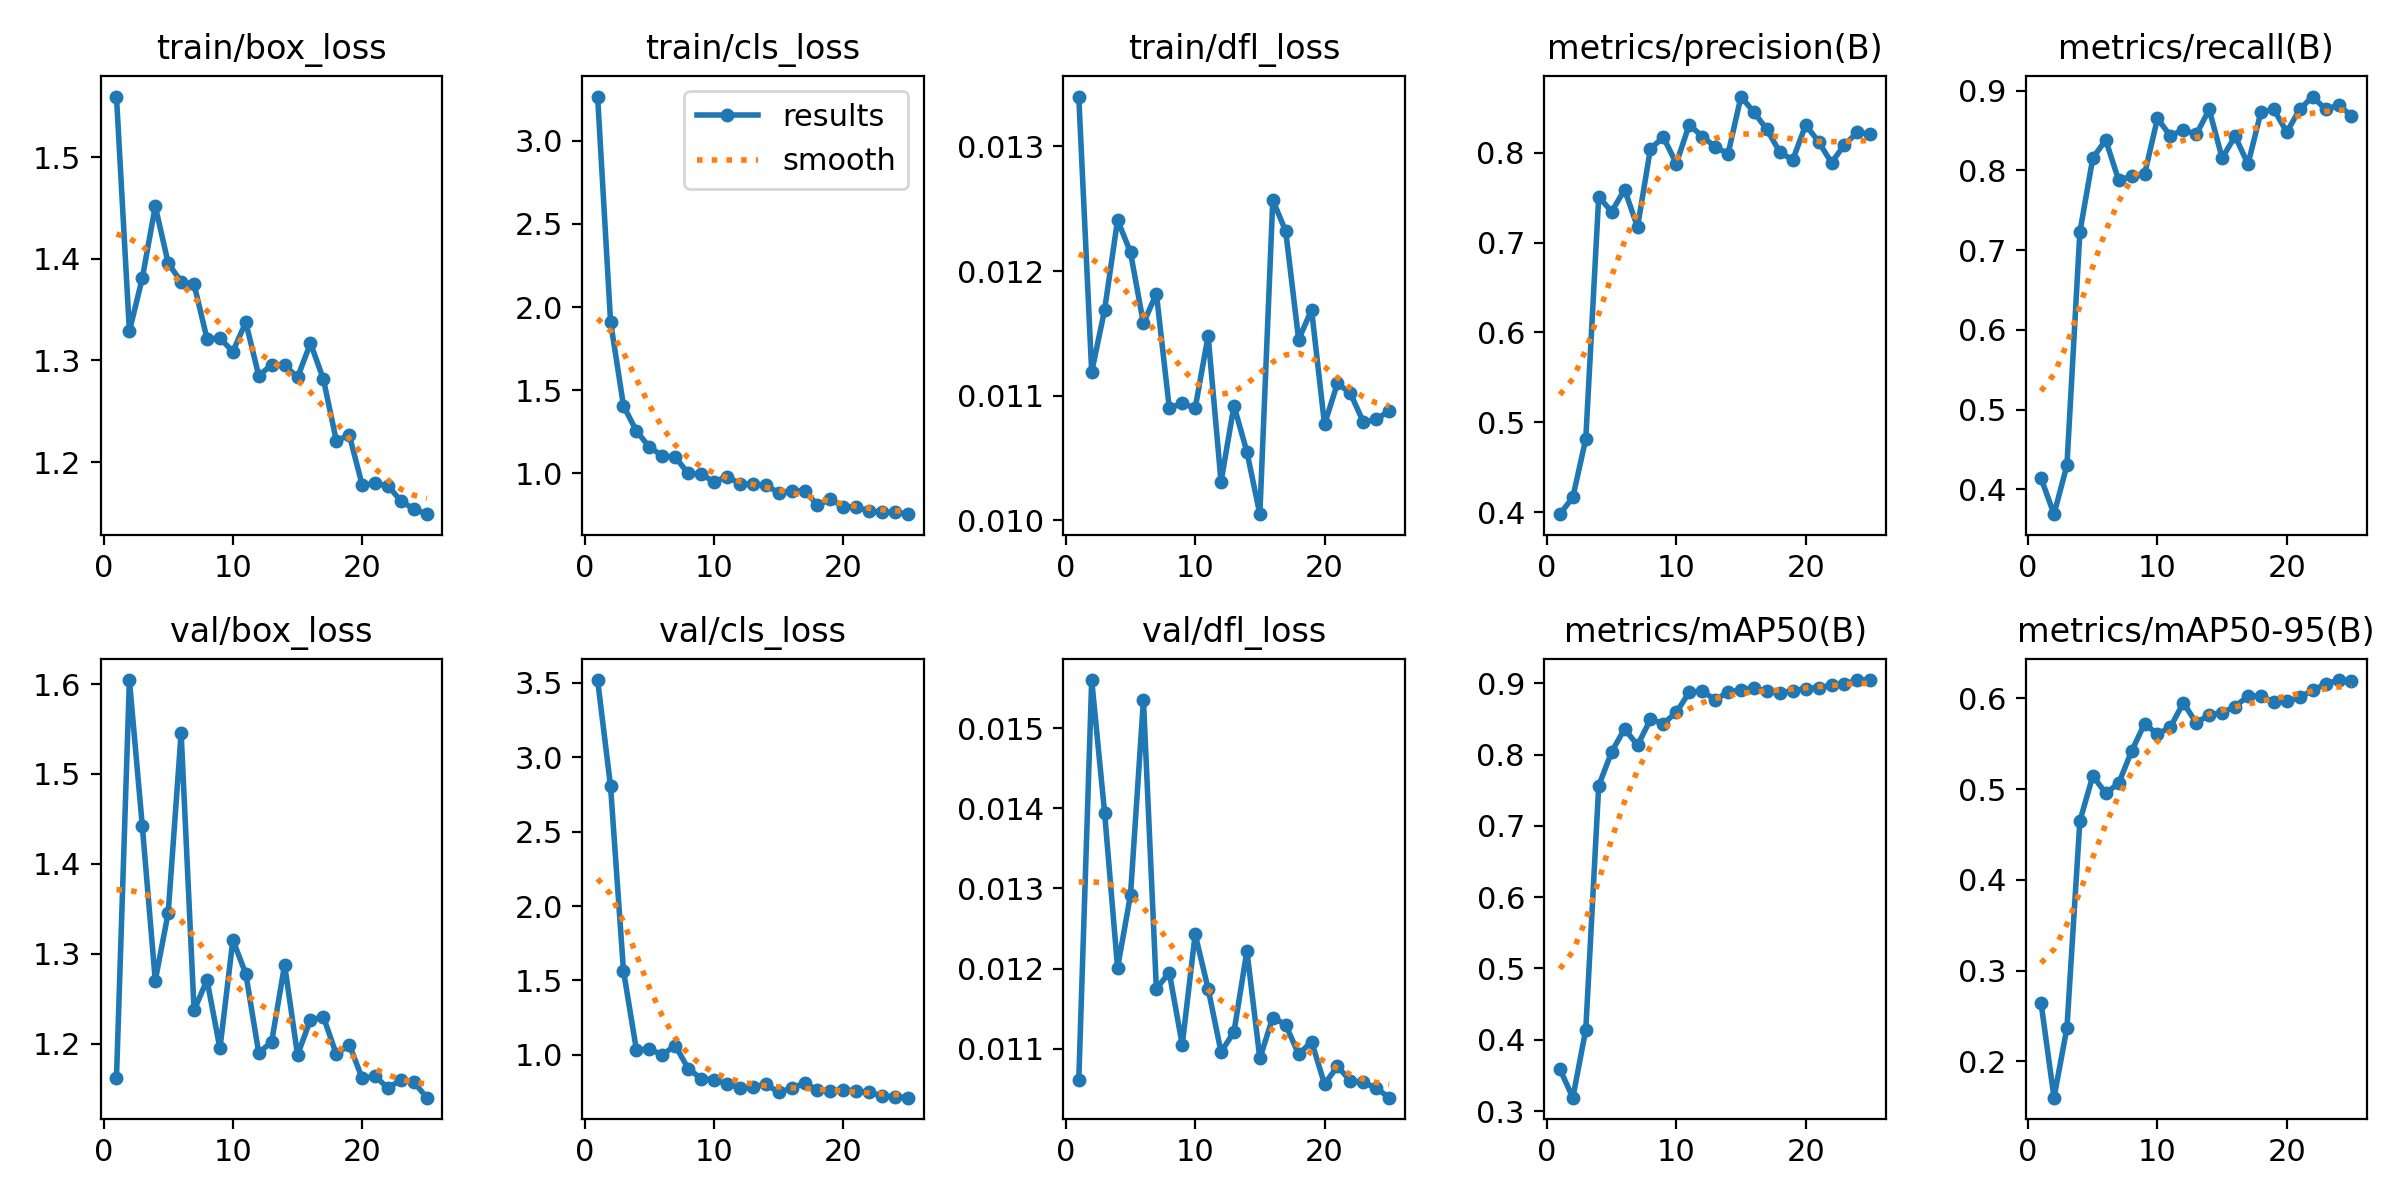

In [12]:
big_curve = os.path.join(run_dir, "results.png")
if os.path.exists(big_curve):
    display(Image(filename=big_curve, width=900))

**8. Prediction Examples (at least 6 on validation images)**


image 1/1 /content/drive/MyDrive/bccd_dataset/valid/images/BloodImage_00147_jpg.rf.69c6ff6d7c4ee7785e06bd34dd937f9f.jpg: 320x320 1 Platelets, 3 RBCs, 1 WBC, 208.9ms
Speed: 4.2ms preprocess, 208.9ms inference, 0.7ms postprocess per image at shape (1, 3, 320, 320)
Results saved to /content/runs/detect/predict


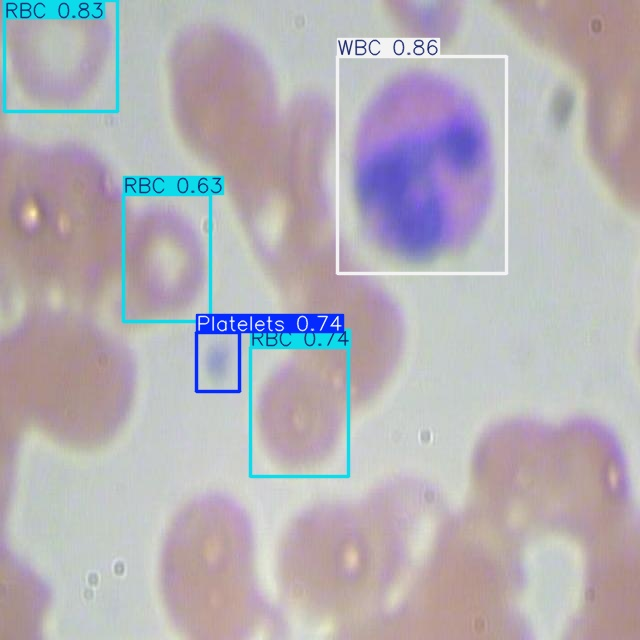


image 1/1 /content/drive/MyDrive/bccd_dataset/valid/images/BloodImage_00217_jpg.rf.159afcd04a7bd8aaed75a230752badcf.jpg: 320x320 2 Plateletss, 12 RBCs, 1 WBC, 171.5ms
Speed: 2.6ms preprocess, 171.5ms inference, 0.4ms postprocess per image at shape (1, 3, 320, 320)
Results saved to /content/runs/detect/predict


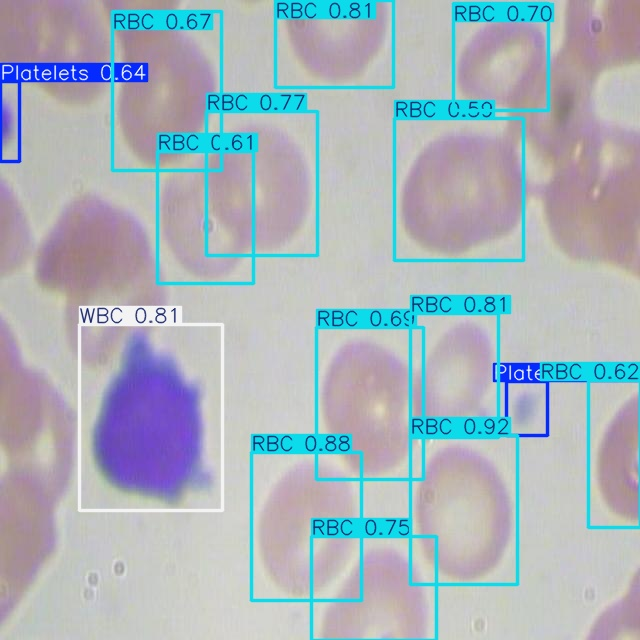


image 1/1 /content/drive/MyDrive/bccd_dataset/valid/images/BloodImage_00031_jpg.rf.fee86d6add4d4c5c248d1af4f4d46f73.jpg: 320x320 3 Plateletss, 13 RBCs, 2 WBCs, 168.0ms
Speed: 1.3ms preprocess, 168.0ms inference, 0.3ms postprocess per image at shape (1, 3, 320, 320)
Results saved to /content/runs/detect/predict


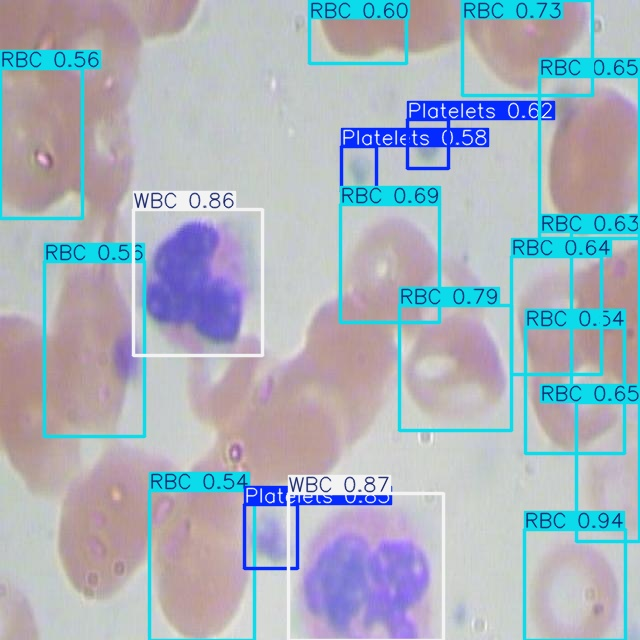


image 1/1 /content/drive/MyDrive/bccd_dataset/valid/images/BloodImage_00303_jpg.rf.d9c3a8b7969438c46be2334cfaefda47.jpg: 320x320 7 RBCs, 1 WBC, 166.0ms
Speed: 3.1ms preprocess, 166.0ms inference, 0.3ms postprocess per image at shape (1, 3, 320, 320)
Results saved to /content/runs/detect/predict


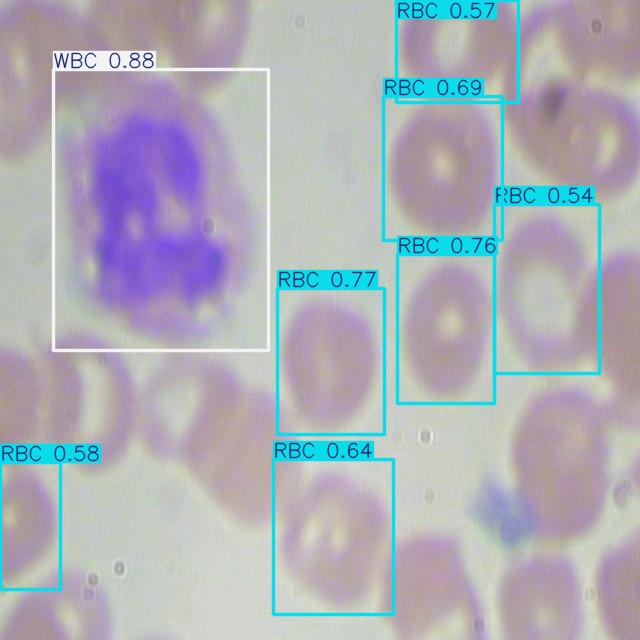


image 1/1 /content/drive/MyDrive/bccd_dataset/valid/images/BloodImage_00311_jpg.rf.874d3a21693972bb4366d1bc38577e1f.jpg: 320x320 1 Platelets, 7 RBCs, 1 WBC, 168.1ms
Speed: 1.4ms preprocess, 168.1ms inference, 0.3ms postprocess per image at shape (1, 3, 320, 320)
Results saved to /content/runs/detect/predict


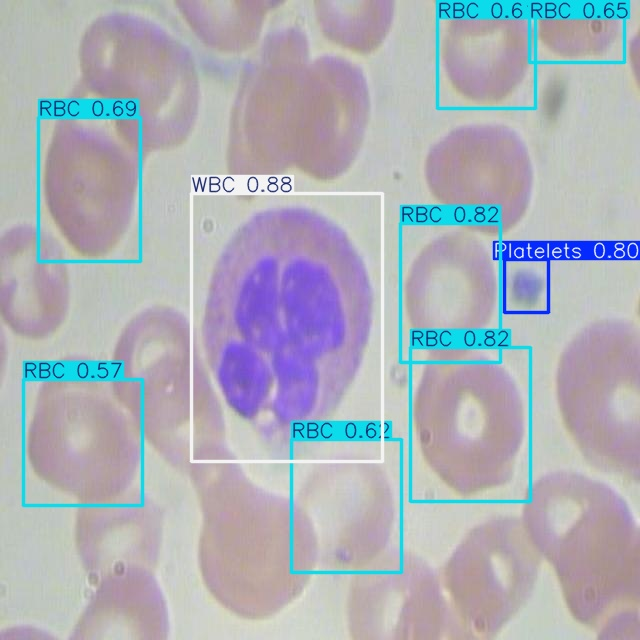


image 1/1 /content/drive/MyDrive/bccd_dataset/valid/images/BloodImage_00081_jpg.rf.26b7e2f9e7233fd5cf5eff51e122163a.jpg: 320x320 2 Plateletss, 9 RBCs, 1 WBC, 164.6ms
Speed: 1.4ms preprocess, 164.6ms inference, 0.3ms postprocess per image at shape (1, 3, 320, 320)
Results saved to /content/runs/detect/predict


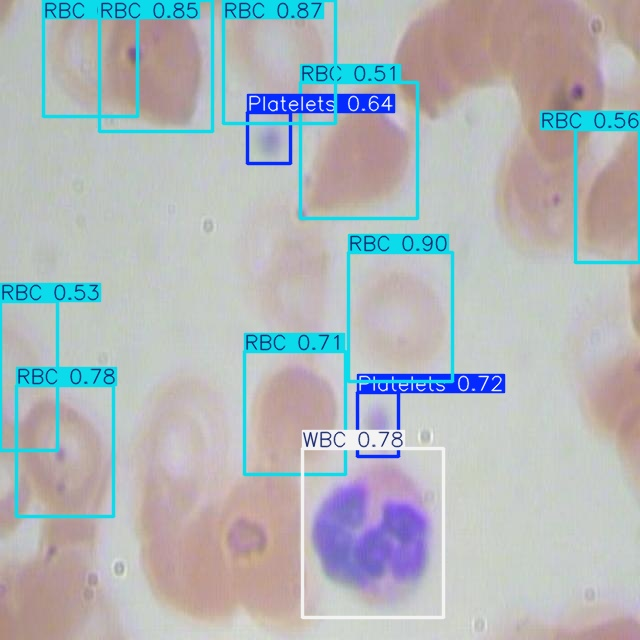


image 1/1 /content/drive/MyDrive/bccd_dataset/valid/images/BloodImage_00332_jpg.rf.de4e8eac9bb1d5764fcf90e5dd1764b8.jpg: 320x320 12 RBCs, 1 WBC, 189.7ms
Speed: 1.5ms preprocess, 189.7ms inference, 0.3ms postprocess per image at shape (1, 3, 320, 320)
Results saved to /content/runs/detect/predict


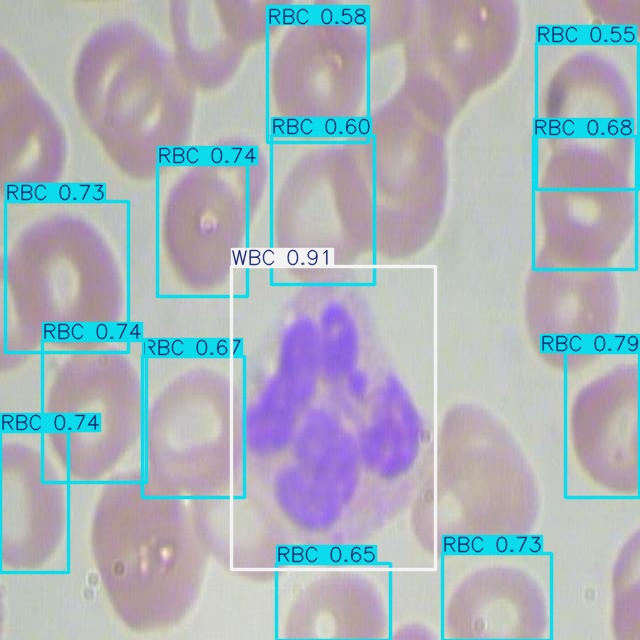


image 1/1 /content/drive/MyDrive/bccd_dataset/valid/images/BloodImage_00281_jpg.rf.5389f4d958eca8626a12755bb8216279.jpg: 320x320 1 Platelets, 13 RBCs, 1 WBC, 173.5ms
Speed: 1.4ms preprocess, 173.5ms inference, 0.4ms postprocess per image at shape (1, 3, 320, 320)
Results saved to /content/runs/detect/predict


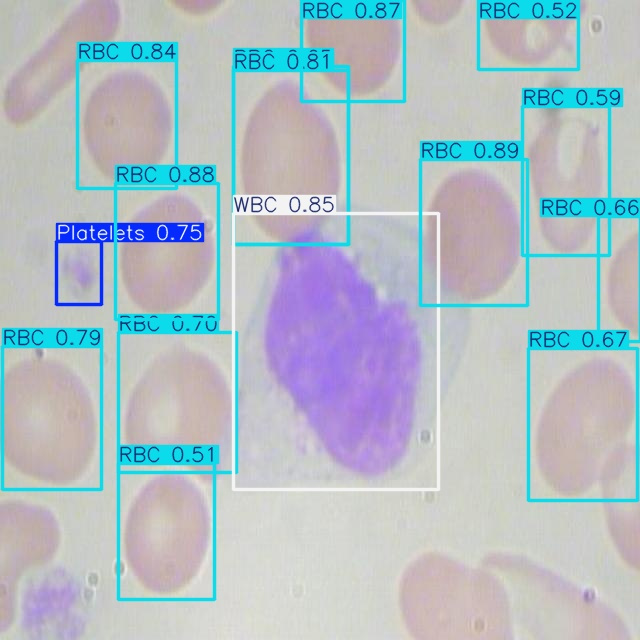

In [13]:
val_images = glob.glob(os.path.join(dataset_path, "valid", "images", "*.jpg"))[:8]

for img_path in val_images:
    preds = model.predict(img_path, conf=0.5, save=True)
    saved_img = os.path.join(preds[0].save_dir, os.path.basename(img_path))
    if os.path.exists(saved_img):
        display(Image(filename=saved_img, width=500))

**9. Confusion Matrix & PR Curve**

Checking visualization files...


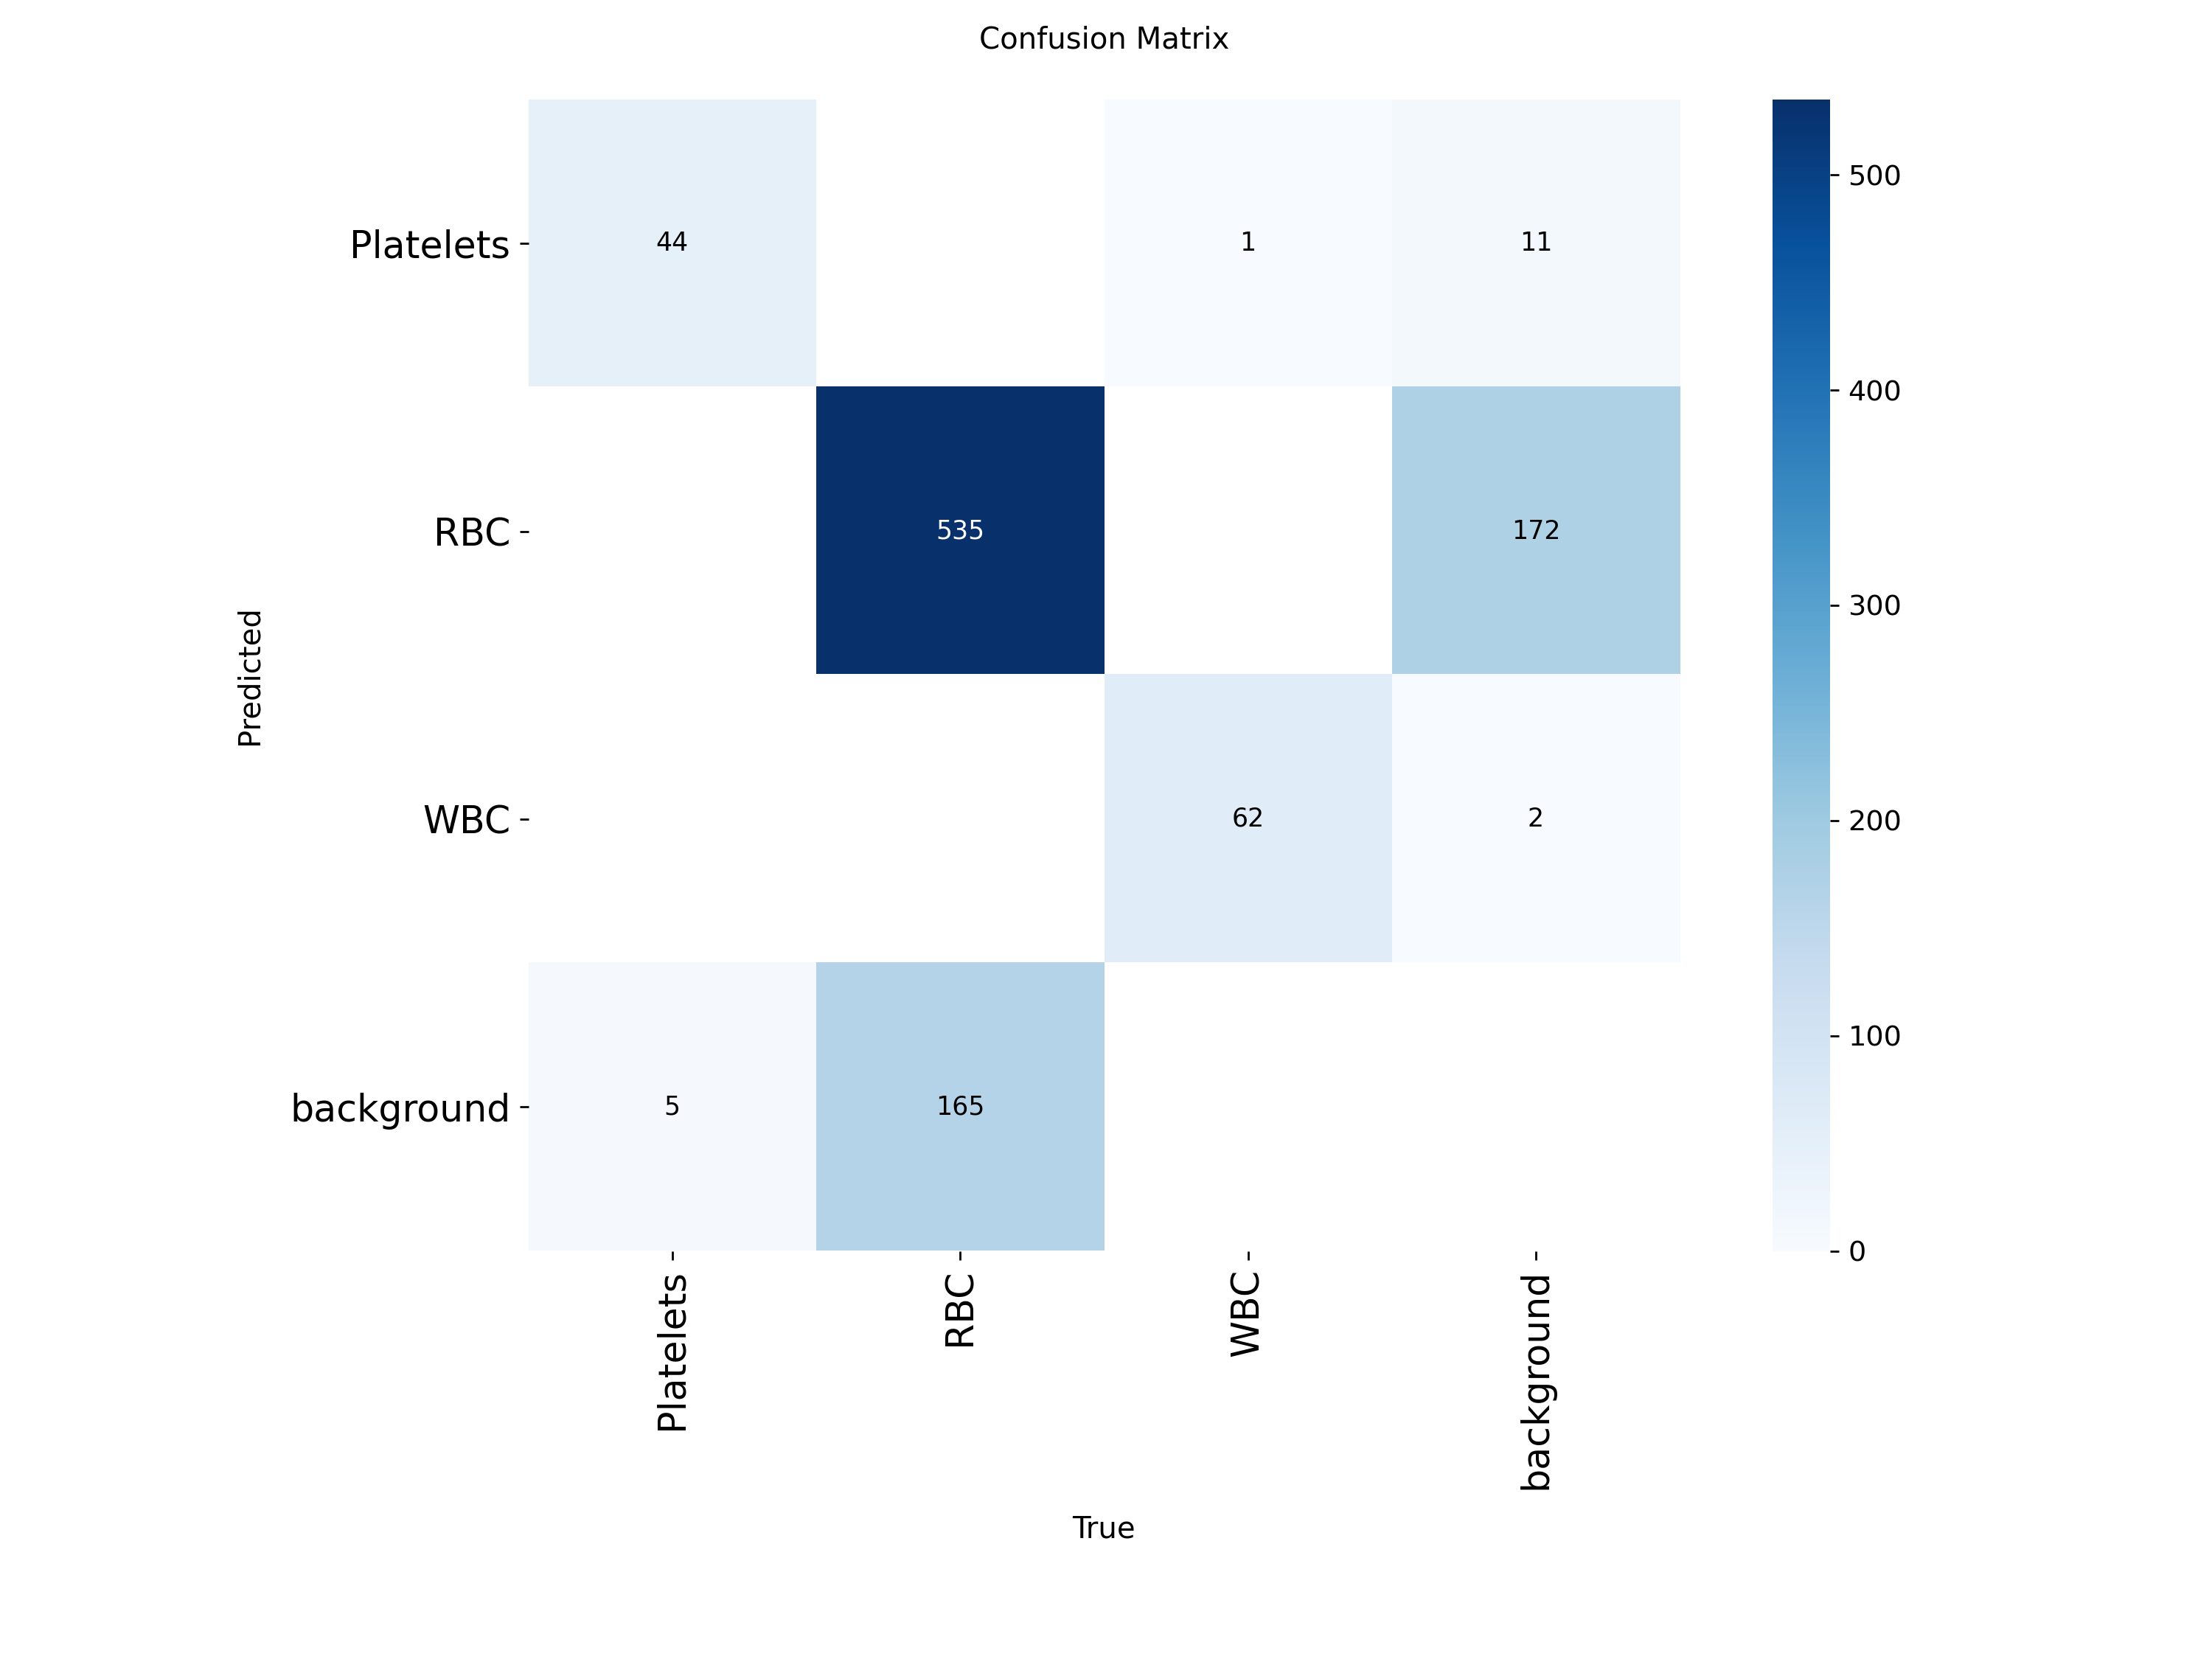

 confusion_matrix.png displayed
 PR_curve.png not found (common with batch=4 + imgsz=320)

 Notebook is complete!
All my plots are saved in the 'individual_plots_for_report' folder.


In [19]:

run_dir = "/content/runs/detect/bccd_yolo26s_group2_320"

cm_path = os.path.join(run_dir, "confusion_matrix.png")
pr_path = os.path.join(run_dir, "PR_curve.png")
f1_path = os.path.join(run_dir, "F1_curve.png")

print("Checking visualization files...")

if os.path.exists(cm_path):
    display(Image(filename=cm_path, width=700))
    print(" confusion_matrix.png displayed")
else:
    print(" confusion_matrix.png not found")

if os.path.exists(pr_path):
    display(Image(filename=pr_path, width=900))
    print(" PR_curve.png displayed")
else:
    print(" PR_curve.png not found (common with batch=4 + imgsz=320)")

if os.path.exists(f1_path):
    display(Image(filename=f1_path, width=900))

print("\n Notebook is complete!")
print("All my plots are saved in the 'individual_plots_for_report' folder.")